# Feature analysis — method + worked example

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`price_dislocation` function in §3. The data loading, the checks, and the plots adapt on
their own.

**The example** is `price_dislocation`: how far another exchange's price has drifted from
byb's. When one exchange moves and the others haven't caught up yet, that gap predicts the
catch-up. It's a good teacher because it touches every step.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or imbalance is already comparable across markets.
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the
  dislocation legs, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a new mid, a byb move — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update), **even between trade ticks**: a gap
  leg refreshes its front to that timestamp's gap; a flow pushes that timestamp's one sample. A value
  that ignores the timestamps since the last trade is **stale** — wrong, and a silent
  source of lag. The choice of EMA *and when it updates* is what makes the inter-trade read
  well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for OFI, a byb book update; for `σ_ev`, a byb mid-move; for trade volume, the trade
  flow itself. A timestamp with only **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp
  (trade volume; OFI sums its intra-timestamp increments). So a backed-up burst of N book updates at one
  instant is still **one** weight-1 sample — value = the final book, or the summed flow — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight on the `E/W` mean at one timestamp) and corrupts the count `W` that normalises it. The
  level-read face of the same trap: `σ_ev` counts squared mid-*moves*, so N simultaneous records
  fabricate N−1 phantom moves and inflate volatility (per-record, σ_ev read **0.13** off; one sample per
  timestamp made it **bit-exact**). Time-order matters only on the clock — a timestamp with trades
  advances it **once**, not once per print.
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once
  per trade-timestamp (that fixes its memory in trade-count), but its *read* must use the latest data: fold
  in the current value as of now — the latest relevant timestamp (mid-move / book update) since the last
  trade — never the stale snapshot frozen at the last trade tick. Use a trade-weighted EMA with a **live
  front**: `read = (1 − α)·committed + α·current_value`, current between trades. Keep the two clocks
  separate, though: refresh the *read* at each relevant **timestamp**, but keep the *decay/weighting* on
  the trade clock — push a fresh *sample* once per book-update **timestamp** (one per timestamp, not per
  message); pushing per message would *message-rate-weight by quote activity*, which here cost ~0.01–0.02
  rank-IC by up-weighting churny stretches the trade clock usefully filters out. (Freshness itself measured ≈neutral for a 100 ms target — so reading fresh
  costs nothing and is the right default; never deliberately use stale information.)
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (a per-exchange
  trade-flow, or byb's own mid-moves — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that a +gap on one exchange can cancel a −gap on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass, and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how far another exchange's price sits from byb's, compared over two time-scales |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Take the log price gap between another exchange and byb:
`gap = log(other price) − log(byb price)`. Smooth it two ways — a *fast* average and a *slow*
one — and look at the difference. A large fast-minus-slow means the gap just opened; gaps tend
to close, so it predicts byb's next move.

**Why it should work.** Exchanges don't move in lockstep — one tends to react a beat before
the others. A fresh gap is that beat, and byb closing it is the prediction. (We don't measure
the exact lag in this notebook; "a beat" is roughly tens of milliseconds.)

**What would disprove it.** No predictive power at any time-scale, or power that vanishes
once we account for how volatile the market is (meaning it was only tracking volatility).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*; never hard-code one as the leader. (This feature is a
> *gap between* exchanges, so it's per-exchange anyway — §9 covers when that choice is genuine
> for poolable features.)

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). If that relevant event is a trade flow, the same
timestamp both injects the flow sample and ticks the shared clock; if the trade is irrelevant to that
EMA, it only ticks. Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (byb's mid-moves, a per-exchange trade flow): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that
  carry the quantity, so the read is a *per-event mean*.
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap): use
  **`LiveFrontEMA`**, which reads the committed mean carried one step toward the freshest value,
  `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) |
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a byb move; trade volume: push summed volume on a trade timestamp) |

Classify the timestamp for the EMA being updated. For `σ_ev`, a trade-only timestamp decays the clock
and injects no sample. For trade volume, that same timestamp injects the timestamp's summed volume and
ticks the shared clock once.

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  EMA must *update* at every timestamp that can move it (same-timestamp events as one update), and the read must reflect the timestamps since the last
  trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  update (one mid, one move, one refresh).

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. Book-update timestamps between trades refresh what the EMA *reads*, but
they do **not** advance the clock — only a trade does, decaying each EMA once.

**Comparable across calm and wild markets** — a raw price gap is simply bigger when the market is
volatile, so on its own it just re-reports volatility. We divide that out with a volatility
**yardstick**, `σ_ev`. (You don't normalise every feature — one that's already a ratio needs none — but
when a feature carries volatility you want gone, divide by the **model's** yardstick, not a fresh
estimate, so the feature lands in the units the model trains in.)

Put the three together — two EMAs of the gap, a fast and a slow, their difference divided by `σ_ev`:

**2a — The shape** (the whole idea, in one line):

`feature = (fast EMA − slow EMA of the gap) / σ_ev`

A fresh gap shows up as the fast EMA pulling away from the slow one, so a large `fast − slow` says the
gap just opened; dividing by `σ_ev` puts it in volatility units. Stop here and you have the feature —
the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **The gap legs** (`fast`, `slow`) are a **forward-filled level** — the gap has a value at every
  instant — so each leg is a **`LiveFrontEMA`** read as a **live front**: `(1 − α)·(value committed at
  the last trade) + α·(the gap right now)`. We **commit** the gap once per trade-timestamp (trade-dwell weighting,
  the right average for a level) and **refresh** the live front at each book-update timestamp, so the read is
  current between trades, never frozen. `n_fast = 1` sets `α = 1`, collapsing that leg to the fresh gap
  itself (no smoothing). One subtlety: both legs read the *same* fresh gap, so it does **not** fully
  cancel in the difference — `fast − slow` keeps a `(α_fast − α_slow)·gap` term, the freshest-gap kick
  that makes the oscillator react the instant a gap opens.
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** — byb moves on only *some* events — so
  each is a **`KernelMeanEMA`** read as `E / W`: push `byb_return²` (with weight `1`) only on a real byb
  mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*. Dividing by `W` does two
  things, and it works because `E` and `W` carry the *same* decay-and-warm-up factor that cancels in the
  ratio: it removes the move *rate* (so the scale doesn't depend on how often byb moves) and it removes a
  fresh EMA's start-up bias, leaving a per-move volatility comparable in calm and busy markets. Push a
  `0` on a non-move trade instead and this silently becomes vol-per-*trade*, drifting with the trade
  rate. (`λ_ev` is the same move-count `W` divided by an EMA of seconds-per-trade — byb's moves per
  second.)

Both reads obey the two between-trade rules from the section above. §3 builds exactly this; §4
re-derives it from raw events and confirms it to ~4e-13.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and the reference for the gap)
OTHERS      = ["bin", "okx"]                      # the other exchanges; each one's price-gap vs byb is a feature
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [1, 10, 50, 200]                   # fast-EMA spans to sweep (1 = no smoothing)
SLOW        = [100, 500, 2000, 5000]             # slow-EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, used for every feature
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    idx = np.searchsorted(rx, merged_ts, "right") - 1
    return np.where(idx < 0, np.nan, mid[np.clip(idx, 0, len(mid) - 1)])   # nan before the venue's first quote (no future-fill); pre-quote rows are neutralised below
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks react to EVERY byb merged-mid change (the same newest-exchange-time front_levels/trade mid logic) —
# defined at every instant, never the net move per trade. They decay once per TRADE (memory in trade count) but INJECT on
# every byb mid-move, so a value read between trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE
# stream (E = squared returns, W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE:
# E_dt is a per-trade EMA of seconds/trade (flat between trades by construction), so λ_ev = byb mid-moves per second.
# `_flow_at` reads the running E at a grid anchor = committed-per-trade EMA + the partial epoch of moves since the last trade.
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute the feature at each grid point.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup (EMAs + yardsticks)
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

gap_committed = {}                                                             # each other's log gap vs byb, on the trade clock (the committed legs)
for ex in OTHERS:
    g = np.log(mid_on_clock(ex)) - log_mid_byb                                 # nan before ex/byb has quoted (mid_on_clock returns nan pre-quote)
    gap_committed[ex] = np.nan_to_num(g, nan=0.0)                              # no committed gap until both venues have quoted — neutral, and decayed away by WARMUP anyway
def _mid_at(ex, t):                                                # a venue's mid forward-filled to arbitrary times (for the FRESH gap)
    rx, mid = mids[ex]; idx = np.searchsorted(rx, t, "right") - 1; return np.where(idx < 0, np.nan, mid[np.clip(idx, 0, len(mid) - 1)])   # nan before first quote; the finite-mask drops such rows
gap_anchor = {ex: np.log(_mid_at(ex, anchor_ts)) - np.log(_mid_at("byb", anchor_ts)) for ex in OTHERS}   # the gap as of each grid anchor — latest book-update timestamp, never stale
def ema(gap, N):
    if N == 1: return gap                                          # all weight on the latest tick
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], gap)
def price_dislocation(ex, n_fast, n_slow):         # live-front (EMA_next): each leg's committed mean carried to the FRESH gap, read at the grid
    g_committed, g_fresh = gap_committed[ex], gap_anchor[ex]
    af, as_ = 2.0 / (n_fast + 1.0), 2.0 / (n_slow + 1.0)
    fast = (1.0 - af) * ema(g_committed, n_fast)[tick_at_anchor] + af * g_fresh     # (1-α)·committed-at-last-trade + α·fresh-gap  (the LiveFrontEMA read)
    slow = (1.0 - as_) * ema(g_committed, n_slow)[tick_at_anchor] + as_ * g_fresh
    return (fast - slow) / sigma_at_anchor
print(f"grid: {len(anchor_ts):,} anchors")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two
agree on real data — a **parity check**, not an independent oracle. The streaming build is the **production** reference: an O(1) state machine you push **raw
events** into — `on_book(...)` for a top-of-book update, `on_trade(...)` for a trade — and read the
current feature per gap from `value()`. State is a few scalar EMAs per gap plus σ_ev's two EWMAs — no
buffers, no history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by its full listing (e.g. `byb_eth_usdt_p`) and keyed by it, so a
  perp and a spot on one exchange stay separate books. It builds each mid **itself** (per `MID_STREAM`):
  merged venues (byb, okx) fuse trades into the book by newest-exchange-time; the book-only venue (bin)
  takes the latest snapshot — so the live mid matches the analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which refreshes each gap leg's live front and injects σ_ev on a byb mid-move, then advances
  the clock **at most once** (decay σ_ev, commit each leg) and only if a trade landed. A book-only
  instant moves the mid without advancing the clock.
- `value()` returns the live front `(fast − slow) / σ_ev` per gap, current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **one** builder and read
**both** gaps (byb↔okx, byb↔bin) at each grid anchor. If the online build reproduces §3's vectorized
feature on real data, the two implementations agree.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA, LiveFrontEMA   # E/W flow mean (σ_ev) + live-front level read (gap legs), src/boba/ema.py

class LiveDislocation:
    # Pure feature state machine. σ_ev is a KernelMeanEMA (E/W flow). Each gap leg is a LiveFrontEMA: it reacts to EVERY
    # book update (on_book / on_trade only update bid/ask; the driver calls refresh() once per timestamp, which pushes the
    # fresh gap into each leg) and reads the LIVE FRONT — never a stale last-trade
    # value. refresh() also advances the clock once per timestamp — decay σ_ev, commit each leg — but only if a trade landed; value() reads the live-front feature per gap.
    # State is O(1), all scalar — no buffers, no history. WHEN to read (record value) is the caller's job.
    # State is keyed by full listing (so a perp and a spot on one exchange never collide). The mid is built INSIDE —
    # never read from merged_levels. Per-listing policy mirrors MID_STREAM: `fuse_trades` listings fold trades into the
    # book by newest-exchange-time (= merged_levels); the rest are book-only, latest snapshot (= front_levels).
    def __init__(self, target, others, n_fast, n_slow, vol_span, fuse_trades):
        self.target, self.others = target, list(others)                    # target listing + the listings we gap it against
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades (merged_levels); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vol = KernelMeanEMA(vol_span)                                 # σ_ev: E/W mean of byb's squared moves -> sqrt(E/W)
        self.leg_f = {o: LiveFrontEMA(n_fast) for o in self.others}        # fast leg of each gap — live-front read of the gap level
        self.leg_s = {o: LiveFrontEMA(n_slow) for o in self.others}        # slow leg
        self.prev = None                                                   # byb's last log-mid, to detect a real move
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one decay per timestamp

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: update the EMAs, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one decay, not many
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        if self.prev is not None and lt != self.prev:
            self.vol.add((lt - self.prev) ** 2)                        # σ_ev reacts to EVERY byb mid-move — a real move injects its return²
        self.prev = lt
        for o in self.others:
            m = self._mid(o)
            if m is not None:
                g = math.log(m) - lt                                    # the gap = log(other_mid / byb_mid)
                self.leg_f[o].add(g); self.leg_s[o].add(g)              # refresh the live front (decay waits for the tick below)
        if traded: self.tick()                                          # a trade landed -> advance the clock exactly once: decay σ_ev, commit each gap leg

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse_trades:                                  # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged-mid listings only) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True                                    # any trade this timestamp -> the clock advances once (in refresh)

    def tick(self):                                                       # advance the trade clock ONE step (refresh calls this at most once per timestamp): decay σ_ev, commit each gap leg
        self.vol.tick()                                                  # σ_ev decays one trade-tick
        for o in self.others:                                          # commit each gap leg's current value (trade-dwell weighting)
            self.leg_f[o].tick(); self.leg_s[o].tick()

    def value(self):                                                      # live-front feature per gap: (fast − slow)/σ_ev, reading the freshest gap — never stale
        sig = self.vol.value() ** 0.5                                    # σ_ev = sqrt(E/W)
        return {o: (self.leg_f[o].value() - self.leg_s[o].value()) / sig for o in self.others}

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 10, 100, 200_000                  # validate BOTH gaps (byb↔okx, byb↔bin) over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once per timestamp, and READ value() at every grid anchor ---
# (the builder stores nothing and has no callback — when to tick/read lives entirely out here). We read AT the anchor —
# after every book-update timestamp up to it — so the live front is genuinely fresh, never the value frozen at the last trade.
fuse = {f"{ex}_{COIN}" for ex in ("byb", "okx", "bin") if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feat = LiveDislocation(TARGET, [LISTINGS[1], LISTINGS[2]], NF, NS, YARDSTICK_N, fuse)           # others: okx, bin
na = min(N_GRID, len(anchor_ts))                                                                # the validated grid slice
streams = {o: np.full(na, np.nan) for o in ("okx", "bin")}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        v = feat.value()
        for o in ("okx", "bin"): streams[o][ai] = v[f"{o}_{COIN}"]
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh()                                 # apply the timestamp: update EMAs, then advance the clock ONCE if any trade landed (one decay per timestamp, not per print)
while ai < na:                                     # trailing anchors after the last event
    v = feat.value()
    for o in ("okx", "bin"): streams[o][ai] = v[f"{o}_{COIN}"]
    ai += 1

# --- one stream -> two live-front features: check EACH gap against its §3 vectorized feature ---
print(f"one raw-event stream -> two live-front features, vs the vectorized build (Nf={NF}, Ns={NS}):")
for o in ("okx", "bin"):
    ref = price_dislocation(o, NF, NS)[:na]
    both = np.isfinite(streams[o]) & np.isfinite(ref)
    diff = np.abs(streams[o][both] - ref[both])
    print(f"  byb<->{o}:  max |diff| {np.nanmax(diff):.2e}  on {int(both.sum()):,} grid points")
    assert np.nanmax(diff) < 1e-6, f"live build does not reproduce the byb<->{o} feature"
print("parity: one raw-event stream reproduces BOTH gaps  OK")

streaming 8,280,046 raw events (book + trades, all venues) over ~200,000 grid points...


one raw-event stream -> two live-front features, vs the vectorized build (Nf=10, Ns=100):
  byb<->okx:  max |diff| 2.14e-13  on 200,000 grid points
  byb<->bin:  max |diff| 4.21e-13  on 200,000 grid points
parity: one raw-event stream reproduces BOTH gaps  OK


**Conclusion.** From one stream of ~8 M raw events the builder reproduces **both** vectorized features to
floating-point precision — max |diff| ~4e-13 over ~200k grid points per gap, pure round-off from the
EMAs' recursive last-digit drift. The production shape (one feed in, a feature *per gap* out) computes
exactly what the offline analysis did, on the one shared trade clock — so the two implementations compute the same feature.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) ≈ 140 s here — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all ~1.7 M anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the feature and target are both in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "alpha"                                                  # price_dislocation = a cross-venue signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. A SIGNED price-head alpha like
                                                                       # price_dislocation divides by the same σ_ev as the target, but a signed numerator makes that shared denominator's coupling negligible — verified by the §6 coupling rows -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ 0.00 for the momenta. That is exactly what
we want here: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information, not the regime wearing a disguise.
That's what makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every
fast/slow pair). And the same feature can carry signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads (see the guard rails) — pre-taking `|·|` per exchange would stop the rate head learning
that opposing gaps cancel. The two signals usually live at different time-scales — direction a
smoother, slower feature; intensity a sharp, immediate one — so we sweep the whole family, for
**every exchange**, against both targets, and draw it as heat-maps. We keep *all* exchanges
(never pick one); the only thing we choose is the best time-scale, **per head**.

**How many exchanges to keep is itself time-scale-dependent.** The cross-exchange edge is an
**arbitrage lead/lag** — one venue ticking before another — and that mispricing is closed within
milliseconds. So at **short** time-scales the venues genuinely differ (who's leading whom) and the
signal is worth keeping **per-exchange**; at **long** time-scales the lead/lag is long gone, every
venue carries the *same* drift, and a **single** exchange already says what the rest do — the extra
copies are redundant. Keep all exchanges as the safe default, but what they *add* over one shrinks as
the scale grows (§9 sweeps that cross-over explicitly).

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev` — i.e. "more or fewer moves than usual," using the rate yardstick.

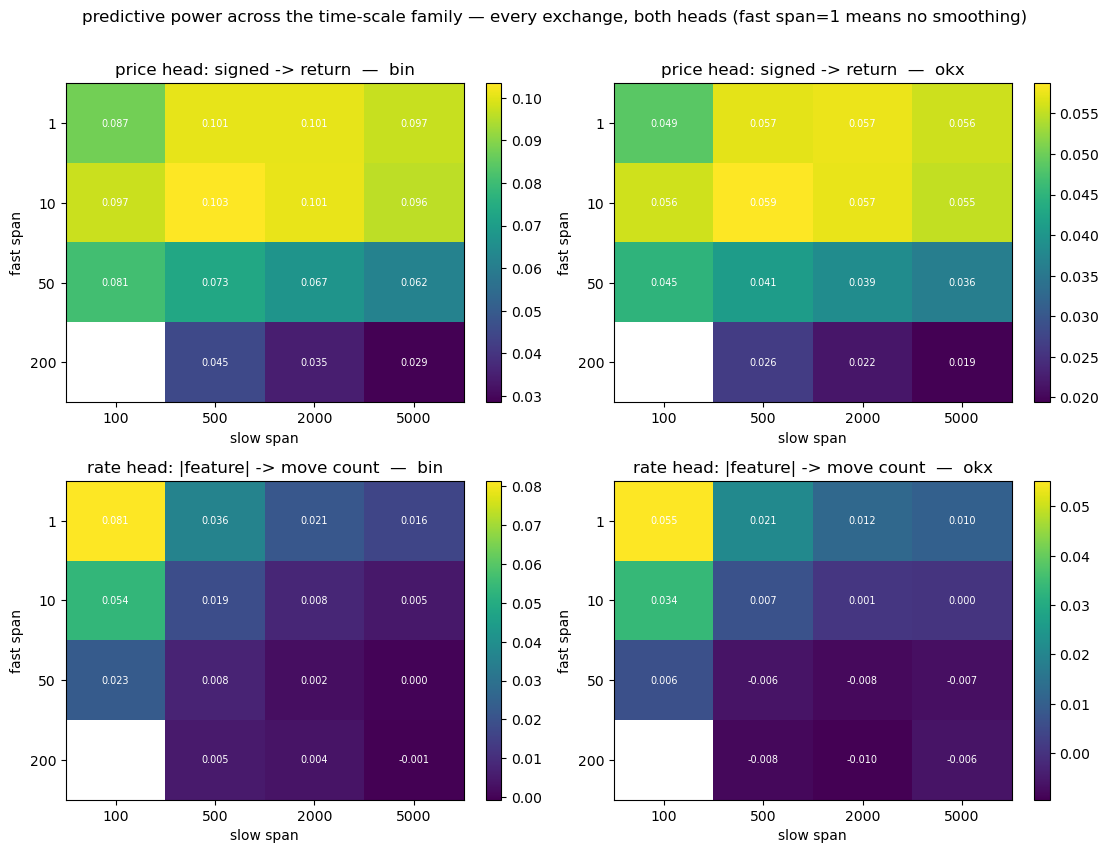

kept features (one per exchange, all fed to the model — none privileged):
  bin:  price head (fast=10, slow=500) power=0.103   |  rate head (fast=1, slow=100) power=0.081
  okx:  price head (fast=10, slow=500) power=0.059   |  rate head (fast=1, slow=100) power=0.055
does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: best alt (f=50,s=500) IC|best -0.024;  OOS joint +0.090 vs solo +0.090 (Δ+0.001)  ->  one span suffices (no OOS gain)


  okx: best alt (f=50,s=500) IC|best -0.017;  OOS joint +0.052 vs solo +0.052 (Δ+0.000)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: best alt (f=10,s=100) IC|best -0.035;  OOS joint +0.071 vs solo +0.071 (Δ-0.001)  ->  one span suffices (no OOS gain)


  okx: best alt (f=10,s=100) IC|best -0.026;  OOS joint +0.048 vs solo +0.050 (Δ-0.003)  ->  one span suffices (no OOS gain)


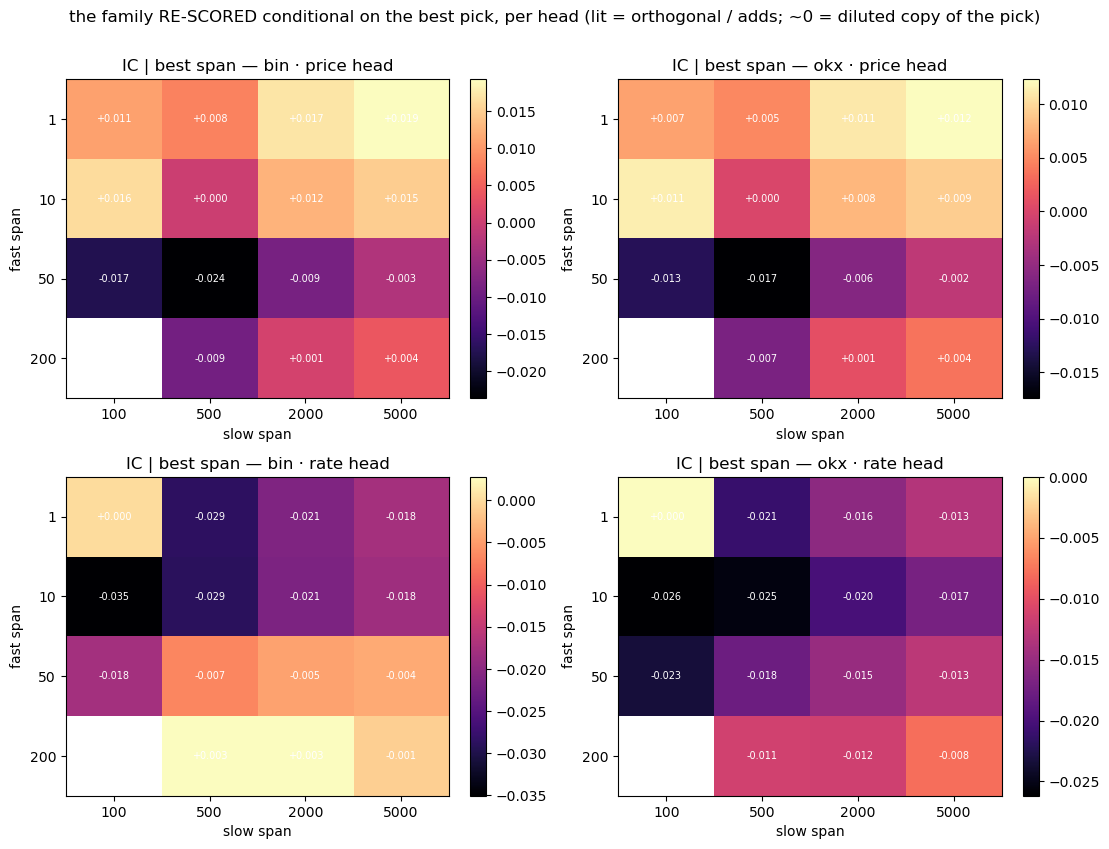

In [5]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Sweep the family for EVERY exchange, BOTH heads, treating exchanges symmetrically (no assumed leader).
# Which exchange carries signal, and when, varies over time -> let the sweep show it; never hard-code one.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in OTHERS}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in OTHERS}   # |feature|      -> byb's move count
for ex in OTHERS:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = price_dislocation(ex, nf, ns)
            price_grid[ex][i, j] = spearmanr(d, target).statistic            # predictive power for the price head
            rate_grid[ex][i, j]  = spearmanr(np.abs(d), rate_target).statistic  # rate head — |feature|→count is a univariate DIAGNOSTIC; the model is fed signed d

fig, axes = plt.subplots(2, len(OTHERS), figsize=(5.6 * len(OTHERS), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: signed -> return"), (rate_grid, "rate head: |feature| -> move count")]):
    for col, ex in enumerate(OTHERS):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}  —  {ex}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("predictive power across the time-scale family — every exchange, both heads (fast span=1 means no smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# We do NOT pick an exchange (not "the best", not assumed). Every exchange's feature is kept; the model weights
# whichever is leading at the moment. Choosing the best time-scale PER exchange is fine; choosing an exchange is not.
# NB: each grid cell is an IN-SAMPLE spearmanr(d, target) and best_member is the nanargmax over it (in-sample maximisation) — this is
# used ONLY to PICK a time-scale, not to claim out-of-sample power. The chosen feature is then re-scored OUT-OF-SAMPLE by the §5
# walk-forward gates below, and that is the number that counts.
def best_member(grid): return np.unravel_index(np.nanargmax(grid), grid.shape)    # best (fast, slow) spans for THIS exchange (in-sample pick)
price_member = {ex: best_member(price_grid[ex]) for ex in OTHERS}                  # one signed feature per exchange (price head)
rate_member  = {ex: best_member(rate_grid[ex])  for ex in OTHERS}                  # one feature per exchange (rate head) — its span is PICKED here by the |feature|→count heat-map (in-sample, like the price pick), then the rate-SPAN feature is put through its OWN Gate A/B below (the rate-head gate cell), against the COUNT target — its verdict is not inherited from the price gates
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in OTHERS:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) power={price_grid[ex][pi, pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) power={rate_grid[ex][ri, rj]:.3f}")

# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a cell to its scored feature, tgt is the head's target, member is the in-sample pick.
HEADS = [("price head", lambda ex, nf, ns: price_dislocation(ex, nf, ns),         target,      price_member),
         ("rate head",  lambda ex, nf, ns: np.abs(price_dislocation(ex, nf, ns)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(OTHERS), figsize=(5.6 * len(OTHERS), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(OTHERS):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"IC | best span — {ex} · {head}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate → |feature| vs the count
target). On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the fast/slow span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 4×4 fast/slow grid (15 valid pairs) of near-identical
neighbours, so the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. Each closes
what the others miss: scale alone passes `z + c·vol_level` (flat std, mean rides the regime); the monotone IC
misses a *U-shaped* leak (`z + |rank(vol) − 0.5|`) that only dispersion catches; and a feature flat in signed
mean and scale can still leak through its *magnitude* into the |·|-fed rate head, which only the magnitude
checks see. The vol/rate level is only the regime *coordinate* here (what we bucket/correlate against),
**never** a control. Fail any
one of them = a level in disguise, not a feature.

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `price_dislocation`
is a cross-venue **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all exchanges together and each on
its own, want ≳ 0.01. *(A **control-type** feature — a regime descriptor like σ_ev/λ_ev — is instead
judged on its **standalone** signal, since marginal-over-its-own-controls is circular; only its
cross-venue legs stay a marginal lead test.)* **Mechanical-coupling guard:** the gate here **always** scores
the **scored target's denominator**. The §6 gate scores the **σ_ev price target** (`fwd_return/σ_ev`) by
default, but `signal_ic(..., tgt=rate_target)` lets a **rate-head control** score `count/λ_ev` instead — and
whichever it scores, a *control ratio* dividing by **that** target's yardstick inflates the IC for a purely
arithmetic reason (the spurious correlation of ratios). The fix is to **stratify by the shared yardstick**
and score *within* strata of it (`STRAT_VAR = sigma_at_anchor` for the σ_ev price target, `lam_at_anchor`
for the λ_ev rate target): stratifying multiplicatively **decouples** the shared denominator, where a linear
partial over-removes the genuine within-yardstick signal (~87% of it). A **signed price-head alpha** needs
none — a signed numerator should make the shared-σ_ev coupling negligible (verified by the coupling rows in the §6 gate table) — so `STRAT_VAR = None`. *(This control-standalone stratified IC is **in-sample**
decoupled, not walk-forward; its out-of-sample confirmation comes from the multi-block harness in `tools/oss`.)*
*Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [6]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
# GATE B — predictive signal.
#   alpha (or a control's CROSS-venue leg): MARGINAL rank-IC over the base momenta — a lead test.
#   control + OWN-venue leg: STANDALONE (marginal-over-own-momenta is circular). If the control RATIO divides
#   by the scored target's yardstick (STRAT_VAR set), score it STRATIFIED by that yardstick — multiplicatively
#   decoupling the shared denominator (HIGH-2), where a linear partial would over-remove genuine signal.
#   own=True selects the standalone branch.
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). The branch logic above is what those functions implement,
# and a control + own-leg with STRAT_VAR=None falls back to a plain (un-decoupled) standalone IC.

disloc = {ex: price_dislocation(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) for ex in OTHERS}
joint = signal_ic(list(disloc.values()), own=False)
strat = signal_ic_by_regime(list(disloc.values()), own=False)
pci = wf_marginal_ci(list(disloc.values()), target)   # H5: per-fold spread + block-bootstrap CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = disloc[OTHERS[0]]                                 # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# GATE A — regime invariance (vol_level/rate_level are the regime COORDINATE, never controls), run PER EXCHANGE
# (Gate A is a property of the output DISTRIBUTION, which differs by venue — bin is sub-ms fresh, byb/okx stale):
# scale, plus the signed feature AND its magnitude |feature| (which the signed-fed rate head can learn), each checked
# two ways x two coordinates — TRACK = |IC(., vol/rate level)| (monotone drift) and DISP = per-decile-mean dispersion
# vs vol OR rate (a NON-monotone, e.g. U-shaped, leak the monotone IC misses); each row reports the WORST coordinate.
# gate_a(feat) comes from boba.research.gates via the §5 wrapper — scale / track / mag / disp vs the vol &
# rate regime coordinates (worst-coordinate per check); it computes its own equal-mass deciles internally.
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all exchanges together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([disloc[ex]], own=False)) for ex in OTHERS]
# H1 shared-σ_ev coupling check: the signed feature AND the σ_ev price target both divide by σ_ev. A SIGNED
# numerator should decouple that shared denominator — verify it (don't assert it): the standalone IC WITHIN
# σ_ev strata ≈ the unstratified standalone IC means σ_ev isn't manufacturing the rank-IC (spurious ratio corr).
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed feature standalone IC, unstratified", value=round(ic(disloc[ex], target), 3)) for ex in OTHERS]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(disloc[ex], target, sigma_at_anchor), 3)) for ex in OTHERS]
for ex in OTHERS:                                       # GATE A PER EXCHANGE (worst coordinate per check) — bin AND okx, since the output distribution differs by venue
    a = gate_a(disloc[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.086  |  per-fold [0.067, 0.094, 0.067, 0.072, 0.13] (positive in 5/5)  |  block-bootstrap 90% CI [0.081, 0.092]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.009 vol 0.013  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all exchanges together — marginal over the invariant control…",0.086
"""B · signal""","""bin alone — marginal over the controls""",0.086
"""B · signal""","""okx alone — marginal over the controls""",0.048
"""B · coupling""","""bin — signed feature standalone IC, unstratified""",0.103
"""B · coupling""","""okx — signed feature standalone IC, unstratified""",0.059
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.101
"""B · coupling""","""okx — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.057
"""A · regime-inv (bin)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.23
"""A · regime-inv (bin)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coo…",0.01


**Conclusion.** `price_dislocation` clears every gate. It adds ≈ **0.086** walk-forward rank-IC over the
controls — jointly and for bin alone (okx alone adds ≈ 0.048, but jointly bin already captures the shared
signal so the joint marginal = bin-alone ≈ 0.086; we keep okx anyway because leadership rotates and its
standalone gain is positive) — far above the ~0.01 floor (**Gate B**); and within σ_ev strata the standalone
IC barely moves (0.103→0.101 bin, 0.059→0.057 okx), so the shared σ_ev isn't manufacturing it. Run **per
exchange** (Gate A is a distribution property — venues differ), it clears every check on **both** legs: scale
wanders only **1.23× / 1.32×** (bin / okx; ≪ 3), the signed feature barely tracks the regime (mean-track
**0.01 / 0.003**), and the magnitude the rate head can learn only weakly tracks it (mag-track **0.073 / 0.091**,
dispersion **0.068 / 0.087**) — all under the ~0.05 / ~0.1 bars, so it's **regime-invariant on every Gate A
check, every exchange** (**Gate A**) — not a level in disguise — and a clean single-block candidate. The
**okx** leg is the looser of the two (mag-track 0.091, brushing the ~0.1 bar) — consistent with its staler
feed, worth watching across blocks. And the companion shows the marginal
gain positive in **all three** regimes — 0.066 / 0.085 / 0.116 for calm / mid / wild — so the signal is
regime-stable, not a one-regime artefact. Verdict for the **price head**: clears every local gate on this
block, **every exchange** — a single-block candidate; shipping is gated by §10. (The rate head is gated separately just below — its verdict is read off the rate-head gate
table, not inherited from these price-head gates.)
The chosen scales match the story — the price head took a lightly-smoothed fast leg over a moderate slow
one (fast=10, slow=500) for both venues; the rate head stayed sharp (fast=1, slow=100).

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the sharp
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model
is fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores
`|feature|`** — a *linear* score on the signed feature would read ≈ 0 precisely because the count
relationship is symmetric, so `|feature|` is the honest proxy for what the nonlinear rate head extracts.
**Coupling guard:** the price head could use `STRAT_VAR=None` because its **signed** numerator decouples the
shared σ_ev; the magnitude path has no sign to decouple it, and `|feature| ∝ 1/σ_ev` while `count/λ_ev ∝
1/λ_ev` share the byb-activity regime — so we add a **within-λ_ev stratified** line per exchange to confirm
the marginal isn't a `1/λ_ev` artefact. **Gate A** is re-run **per exchange** on the rate-span feature (a
distribution property — it differs by venue *and* by span).

In [7]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited
# from the price gates — it gets the SAME two-gate battery here, against the count target.
#  * The rate head's signal lives in the MAGNITUDE: |feature|->count is the §6 diagnostic, and the model is fed the
#    SIGNED feature and recovers |.| internally (a nonlinear head can). So Gate B scores |feature| — a LINEAR score
#    on the signed feature reads ~0 precisely because the count relationship is symmetric; |feature| is the honest
#    proxy for what the nonlinear rate head extracts.
#  * Coupling guard: the price head could set STRAT_VAR=None because its SIGNED numerator decouples the shared σ_ev.
#    The magnitude path has no sign to decouple it, and |feature| ~ 1/σ_ev while count/λ_ev ~ 1/λ_ev share the byb-
#    activity regime — so we add a within-λ_ev stratified line per exchange to confirm the marginal is not a 1/λ_ev artefact.
#  * Gate A is re-run PER EXCHANGE on the rate-span feature (a distribution property — it differs by venue AND by span).
disloc_rate = {ex: price_dislocation(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]]) for ex in OTHERS}
mag_rate    = {ex: np.abs(disloc_rate[ex]) for ex in OTHERS}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)   # H5: per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is defined in the §6 price-gate cell above.

rate_rows  = [dict(gate="B · signal (rate)", detail="all exchanges together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in OTHERS]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in OTHERS]
for ex in OTHERS:
    a = gate_a(disloc_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.028  |  per-fold [0.015, 0.031, 0.037, 0.029, 0.026] (positive in 5/5)  |  block-bootstrap 90% CI [0.023, 0.031]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all exchanges together — marginal |feature|->count over the controls; …",0.028
"""B · signal (rate)""","""bin alone — marginal |feature|->count over the controls""",0.024
"""B · signal (rate)""","""okx alone — marginal |feature|->count over the controls""",0.014
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.07
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.049
"""A · regime-inv (bin)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.18
"""A · regime-inv (bin)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.004
"""A · regime-inv (bin)""","""|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst …",0.08
"""A · regime-inv (bin)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), wor…",0.062


**Conclusion (rate head).** The rate-span feature clears the same battery against the **count** target,
every exchange. **Gate B** — the marginal `|feature| → count` over the controls is **+0.028** jointly,
**+0.024** (bin) and **+0.014** (okx) on their own, all above the ~0.01 floor; and *within* **λ_ev strata**
the signal stays robustly positive (**0.07** bin, **0.049** okx), so the marginal isn't a `1/λ_ev` arithmetic
artefact. **Gate A** holds per exchange — scale **1.18 / 1.20** (≪ 3), signed mean-track **0.004** (≪ 0.05),
and the `|feature|` the rate head actually sees barely tracks the regime (mag-track **0.08 / 0.05**,
dispersion **0.06 / 0.06**, both under the ~0.1 bar). The **companion** is positive in every regime
(**0.019 / 0.030 / 0.030** for calm / mid / wild). So the rate head clears every local gate too — so the
"**both heads, every exchange**" verdict is *earned* **on this block**, not inherited. (The okx rate leg at
0.014 and bin's 0.08 mag-track are the loosest numbers — worth watching across blocks.)

### Self-test — does the stratify-by-yardstick decouple actually work?

The alpha worked example above never exercises the **control** branch (`FEATURE_KIND="control"`, own-leg,
`STRAT_VAR` set), so this small cell checks the one thing that branch relies on: that **stratifying by the
shared yardstick kills a purely-mechanical ratio coupling while keeping a real signal**. We build, on the
grid, a `count/λ_ev`-style rate-head target and two control *ratios that both divide by `λ_ev`* (so
`STRAT_VAR = lam_at_anchor`):
- **pure-spurious** — a numerator with **no** real link to the count, divided by `λ_ev`. Its **raw** Spearman
  against the target is large (the shared `1/λ_ev` manufactures it); **stratified** by `λ_ev` it collapses to ≈0.
- **real-signal** — a numerator that genuinely tracks the count, divided by `λ_ev`. Its raw IC is inflated by
  the same coupling, but the **stratified** IC keeps the genuine within-stratum signal.

If `stratified_ic` returns ≈0 for the spurious ratio (vs a large raw IC) and recovers the real one, the
decouple does what Gate B's control branch needs.

In [8]:
# SELF-TEST of the control-branch decouple (does NOT touch the alpha worked example above).
rng = np.random.default_rng(0)
# a count/λ_ev-style rate-head target on the grid (the same shape rate_target has)
st_count  = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")]).astype(float)   # byb moves over the next 100 ms
st_target = st_count / np.maximum(lam_at_anchor, 1e-9)                               # count ÷ λ_ev (the scored ratio target)
st_lam    = lam_at_anchor                                                            # the shared yardstick == STRAT_VAR

# PURE-SPURIOUS control ratio: numerator independent of the count, divided by the SAME λ_ev -> shares only the denominator.
# Keep the numerator nearly CONSTANT so the shared 1/λ_ev dominates the ratio's variance -> a fake raw IC the stratify removes.
spur_num   = 1.0 + 0.25 * rng.standard_normal(len(anchor_ts))                        # constant-ish, count-independent numerator
spur_ratio = spur_num / np.maximum(st_lam, 1e-9)
# REAL-signal control ratio: numerator that genuinely predicts the count, divided by the SAME λ_ev.
real_num   = st_count + 3.0 * rng.standard_normal(len(anchor_ts))                    # tracks the count (with noise)
real_ratio = real_num / np.maximum(st_lam, 1e-9)

def _raw(f, y):
    m = np.isfinite(f) & np.isfinite(y); return float(spearmanr(f[m], y[m]).statistic)
print("control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):")
spur_raw, real_raw = _raw(spur_ratio, st_target), _raw(real_ratio, st_target)
_k, _s = FEATURE_KIND, STRAT_VAR                                          # BLOCKER-2: exercise the REAL gate path (signal_ic), not stratified_ic directly
try:
    globals().update(FEATURE_KIND="control", STRAT_VAR=st_lam)           # st_lam == lam_at_anchor is genuinely heavy-tailed (ISSUE-5 stress)
    spur_gate = signal_ic([spur_ratio], own=True, tgt=st_target)
    real_gate = signal_ic([real_ratio], own=True, tgt=st_target)
finally:
    globals().update(FEATURE_KIND=_k, STRAT_VAR=_s)
print(f"  pure-spurious:  raw Spearman {spur_raw:+.3f}  ->  signal_ic {spur_gate:+.3f}   (want raw large, gated ~0)")
print(f"  real-signal:    raw Spearman {real_raw:+.3f}  ->  signal_ic {real_gate:+.3f}   (want signal kept)")
assert abs(spur_gate) < 0.04,                      f"stratify failed to kill the spurious heavy-tailed coupling ({spur_gate:+.3f})"
assert abs(spur_raw) > 3 * abs(spur_gate) + 0.04,  f"spurious raw IC not materially larger than gated ({spur_raw:+.3f} vs {spur_gate:+.3f})"
assert abs(real_gate) > 0.05,                      f"stratify destroyed the real signal ({real_gate:+.3f})"
print("  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.")

control-branch decouple self-test — THROUGH signal_ic (target = count/λ_ev, STRAT_VAR = λ_ev, heavy-tailed):


  pure-spurious:  raw Spearman -0.151  ->  signal_ic -0.005   (want raw large, gated ~0)
  real-signal:    raw Spearman +0.133  ->  signal_ic +0.166   (want signal kept)
  OK — the gate's control path decouples the spurious heavy-tailed ratio and keeps the real signal.


## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

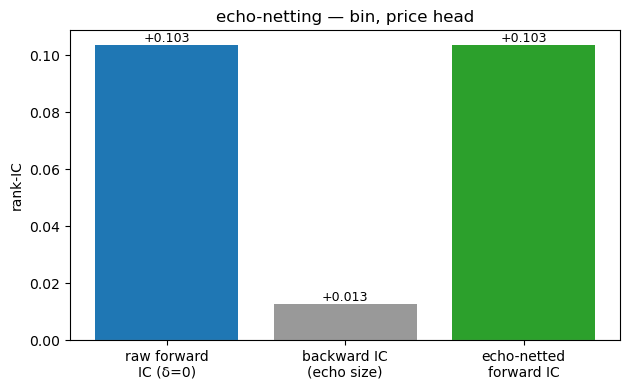

raw forward IC +0.103;  backward (echo) IC +0.013;  echo-netted forward IC +0.103  (the raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = OTHERS[0]                                       # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = price_dislocation(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])   # the chosen price-head feature
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high feature values — it should tilt
  one way as the feature turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the feature's *magnitude* grows.

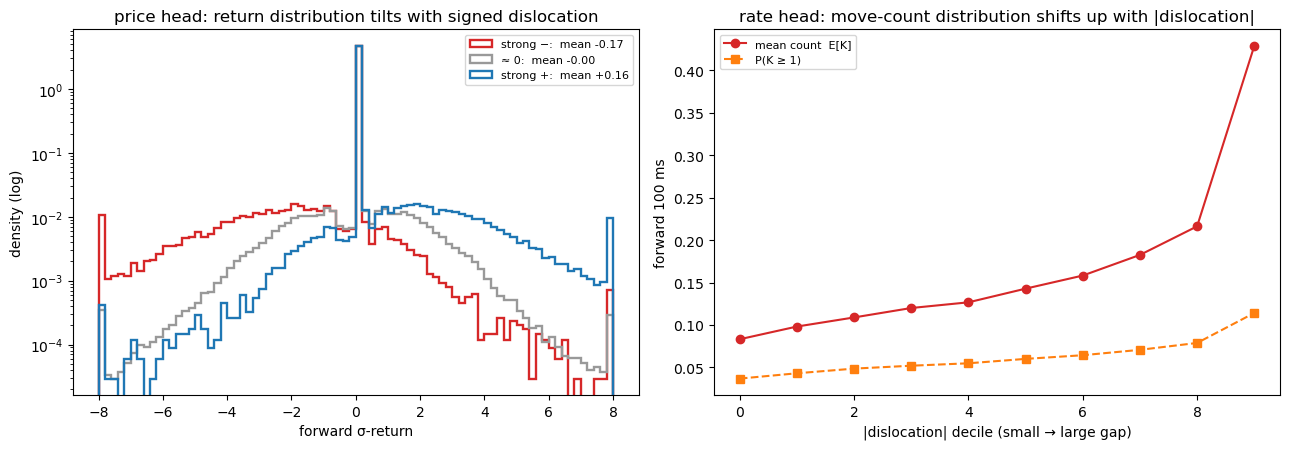

In [10]:
rep_ex = OTHERS[0]                                                              # one exchange shown to illustrate the shape; the model still uses every exchange
signed = price_dislocation(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])
absmag = np.abs(price_dislocation(rep_ex, FAST[rate_member[rep_ex][0]], SLOW[rate_member[rep_ex][1]]))  # deliberately the RATE-head scales (rate_member), not the price-head scales — same feature, rate-head's own span pick
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-dislocation buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed dislocation"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |dislocation|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|dislocation| decile (small → large gap)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |dislocation|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads
need — not just a single summary number. **Price head (left):** the forward-return distribution
shifts bodily with the *signed* feature — a negative mean return for the strong-negative group,
positive for the strong-positive group, with the flat ≈0 group between — so the sign genuinely
carries direction. **Rate head (right):** both the mean move-count `E[K]` and `P(K ≥ 1)` climb
monotonically from the smallest to the largest |dislocation| decile — a big gap really does
precede more catch-up moves. So both heads have something to learn here, in the directions §1
predicted.

## 8. Input shaping for the network

This is a *different* step from §2. There we divided out volatility (the "regime division") so
the feature means the same thing in any market. Here we reshape the feature for the neural
network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score: subtract
the mean, divide by the standard deviation); a heavily skewed or fat-tailed one needs more
(e.g. a rank-to-normal map: sort the values and reassign them onto a bell curve). The plot
makes the choice for you.

feature: std=1.3  skew=+0.02  excess_kurt=1.4  (0 = normal)
  z-score            excess_kurt=   1.4   max|·|=27.8
  robust + clip ±4   excess_kurt=   0.3   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.8   max|·|=4.1
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


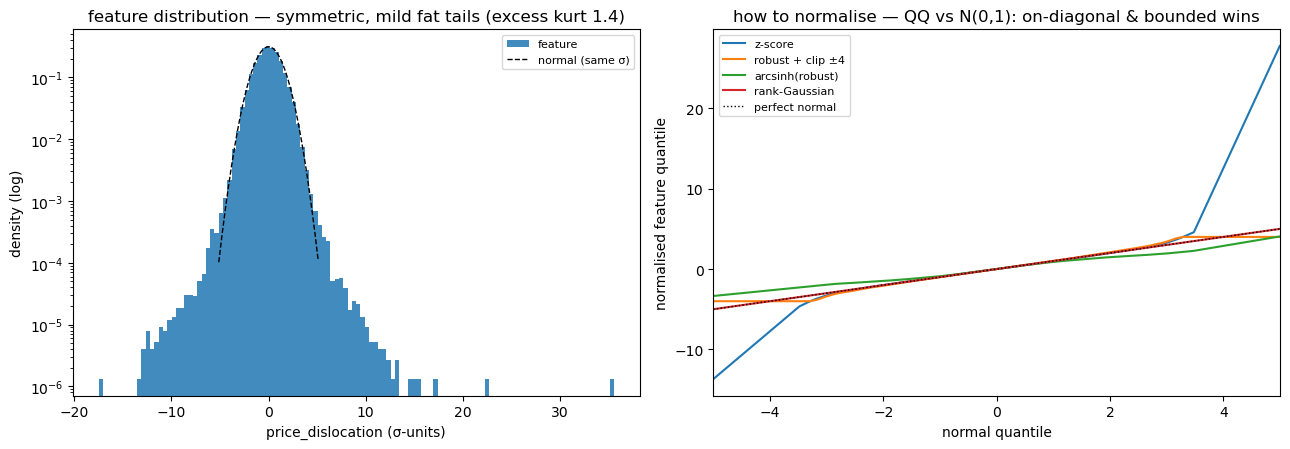

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = OTHERS[0]                                                              # one exchange shown to illustrate the shape (same construction for every exchange)
f = price_dislocation(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.1f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("price_dislocation (σ-units)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — symmetric, mild fat tails (excess kurt {kurtosis(f):.1f})")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** For this feature the printout settles it: it's already near-symmetric (skew ≈ 0)
with only mild fat tails — *because* it's divided by `σ_ev` — so a plain rescale (z-score) keeps
the excess kurtosis low. But it still leaves a ≈28σ spike (max|·| = 27.8), which violates the
"no wild outliers" bar — so the z-score alone doesn't clear it. The lightest transform that
*meets* the bar is a robust z-score followed by a clip (robust + clip ±4 → max|·| = 4.0), so you clip
whenever you feed a network. The heavier transforms (arcsinh, rank-Gaussian) flatten the tails
further but would just throw information away here. A skewed or fat-tailed feature would push you
the other way; the QQ-plot tells you which.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

`price_dislocation` is a *gap between* exchanges, so it has to be per-exchange — there's no
single "pooled" version. But many features (trade-flow, order-flow imbalance, queue
imbalance) *can* be pooled into one number, and then you face a real choice: keep them
**per-exchange**, collapse to **one exchange**, or **pool** them all? The answer depends on
the time-scale, so sweep it and compare the three.

> **The table below is an illustrative example for a poolable trade-flow feature — it is NOT
> computed for `price_dislocation`** (whose real per-exchange numbers are the heat-maps in §6).
> It just shows the typical pattern, predicting byb's next 100 ms. The time-scale
> column is labelled in ms / seconds only for readability — those wall-clock figures are
> just a translation of points on the trade-span N clock; the actual sweep is over trade-span
> N, as everywhere else.

| time-scale | pooled | best single | per-exchange | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.22 | **0.23** | 0.22 | one exchange is enough — splitting just adds noise |
| ~500 ms | 0.11 | 0.12 | **0.16** | keep per-exchange — exchanges genuinely differ here |
| ≥ 2.5 s | 0.08 | 0.08 | 0.09 | exchanges agree — any one will do |

So: at the shortest scales the signal lives in one exchange; in a **middle band** the
exchanges genuinely differ (who's leading whom) and keeping them separate pays off; at long
scales they all converge. In this typical pattern pooling is rarely the best — it tends to blur
the middle-band structure; that's why you sweep and compare the three (per-exchange / single /
pooled) rather than pool by default. (Longer prediction horizons push the useful band wider, so in general
sweep the horizon too.)

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed* feature to both heads (each head gated separately in §6), all exchanges, at
a couple of time-scales each:**
- **Price head (direction):** a fast average over a slow one — here both venues landed on a
  lightly-smoothed fast leg over a moderate slow one (fast=10, slow=500); how much to smooth is a
  per-feature choice, so sweep it.
- **Rate head (intensity):** a sharp pair — an unsmoothed fast leg (n_fast=1) minus a short
  slow leg (n_slow=100), so the difference reacts to the freshest gap.
  The *magnitude* of the gap is what predicts a burst of moves, but you still feed the
  **signed** feature and let the rate head recover that — and learn how exchanges' gaps
  cancel or reinforce. (Feeding pre-`|·|` per exchange would block that.) The rate-span feature
  is put through its **own** Gate A/B battery against the **count** target (the rate-head gate table
  in §6), and clears it on this block — Gate B **+0.028** joint (`|feature| → count`, above the ~0.01
  floor), Gate A within bars per exchange, companion positive in every regime — so "keep it" is
  *earned* for the rate head too, not inherited from the price gates.

Feed **every exchange's** signed feature in and let the model lean on whichever is leading at
the moment; don't collapse to a single "leader." The feature is divided by the volatility
yardstick; the move-count it predicts is divided by the rate yardstick.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version
- [ ] the tests, passing
- [ ] the gate results recorded (with any failures justified)
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the data quirks handled (bad zero-price prints; the right price source per exchange)